=== Reading data from files ===

E(CO) = -591.7251 eV  |  E(OH-) = -457.3979 eV

Computing thermochemical corrections:
  [WARNING] ASE not found; using hardcoded CO corrections.
  OH_ADS_CORRECTION = -3.9793 eV  (back-calculated, implicit solvent)
  OH_LAT_CORRECTION = -3.0764 eV  (back-calculated, implicit solvent)

Loading Bader dQ averages from spreadsheet:
  dQ-Pd  Ag  0% = -0.7473
  dQ-Pd  Ag 25% = -0.7322
  dQ-Pd  Ag 50% = -0.6824
  dQ-Pd  Ag 75% = -0.6565
  dQ-Ag  Ag 25% = -0.5054
  dQ-Ag  Ag 50% = -0.4838
  dQ-Ag  Ag 75% = -0.4834
  dQ-Ag  Ag100% = -0.4826
  dG_CO   (Pd_111               CO_Pd ) raw = -0.9154 eV
  dG_OH*  (Pd_111               OH_Pd ) raw = +0.0569 eV  [0v_intercept]
  mu_OH*  (Pd_111              )  dQ-Pd = -0.7473  [from spreadsheet]
  dG_CO   (Ag25Pd75_111         CO_Pd ) raw = -0.9506 eV
  dG_CO   (Ag25Pd75_111         CO_Ag ) raw = +0.3047 eV
  dG_OH*  (Ag25Pd75_111         OH_Pd ) raw = +0.0319 eV  [0v_intercept]
  mu_OH*  (Ag25Pd75_111        )  dQ-Pd = 

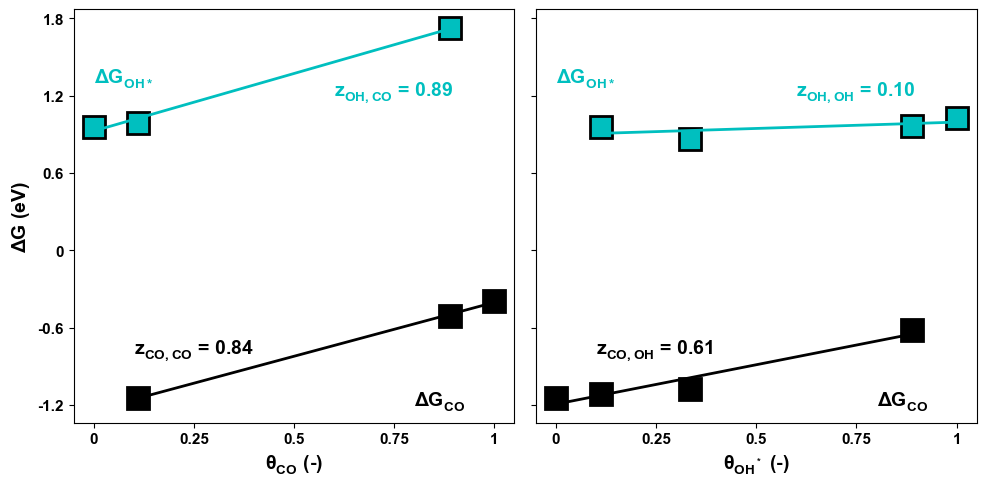

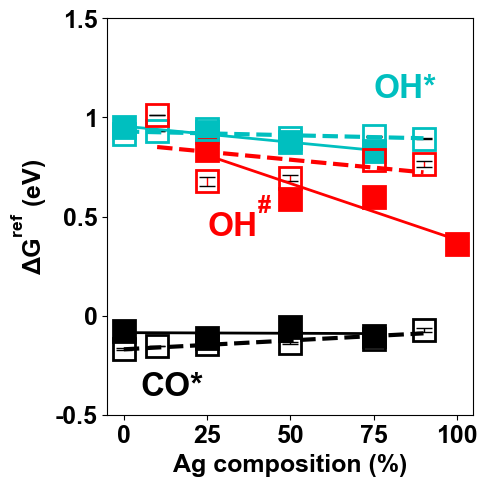

In [1]:
# -*- coding: utf-8 -*-
"""
fitted_and_calculated_params_plotter.py

Plots fitted microkinetic model parameters alongside DFT-calculated adsorption
energies as a function of Ag composition in AgPd(111) alloys.

Data sources
------------
DFT energies        : opt.log files in dft_data/
  Adsorption energy : E_ads = E(slab+ads) - E(slab) - E(mol) + correction
  Lateral int.      : Pd(111) coverage-dependent calculations and CO+OH
                      co-adsorption data at PZC
Model parameters    : *_local_minima.xlsx in modeling_scripts/
  Best fit          : row with minimum positive likelihood value
  Error estimates   : std of parameter across rows within 2x min likelihood
Bader charges       : Bader_dQ_values.xlsx (averaged dQ per composition);
                      falls back to ACF.dat files if not present

Models
------
Pd100  : single-site ER (no lateral interactions)
Alloys : dual-site BLH PCT (no lateral interactions)

Free-energy corrections (eV)
-----------------------------
CO corrections are computed at runtime via ASE IdealGasThermo (see
_compute_co_corrections). Experimental C-O stretch (2143 cm-1) is used as
the only vibrational mode; the dominant contribution is translational and
rotational entropy lost upon adsorption. Falls back to Pd(111)-referenced
hardcoded values if ASE is unavailable.

OH- corrections remain as back-calculated constants (_get_oh_corrections).
Gas-phase thermo is inappropriate for an ion in implicit solvent (~-4 eV
solvation contribution); a proper treatment requires the computational
hydrogen electrode once H2O/H2 molecule calculations are available.

Grand canonical DFT adsorption energies
-----------------------------------------
Slab and adsorbate opt.log files in the voltage subdirectories already
contain JDFTx grand canonical (GC) energies.  The molecular references
(CO, OH-) are corrected manually:

    E_GC(mol, U) = E_mol_ref - N_e * mu_e(U) * 27.2112

where E_mol_ref is the spreadsheet reference energy (eV), N_e the formal
electron count, and mu_e(U) the electrochemical potential in Hartree.

    mu_e(Ha) = -(V_RHE + 4.66 - 0.059*pH) / 27.2112

At 0 V_RHE, pH 13: mu_e = -0.143065 Ha.  CO: N_e=10, E_ref=-592.167148 eV.
OH-: N_e=8, E_ref=-457.662922 eV.

dG_CO is computed directly at 0 V.
dG_OH* is computed at 0.2-1.0 V and linearly extrapolated to 0 V
(the 0 V slab Bader calculation is anomalous for OH-containing slabs).

DFT mu (partial charge transfer)
---------------------------------
mu = delta_Q(OH) + delta_Q(metal), averaged over 0.2-1.0 V.
  delta_Q(OH)    = N_e(H) + N_e(O) - 8
  delta_Q(metal) = N_e(nearest metal in ads slab) - N_e(same metal in clean slab)
Bader charges read from ACF.dat; atom matching by Cartesian position.

NOTE: these mu values will differ from the hardcoded script, which used
re-fitted model results. The final values will be updated after refitting.
"""

import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import openpyxl


def set_rc_params():
    """Set Matplotlib rcParams for publication-style figures.

    Inlined here so this script is self-contained and needs no external
    rcparams_settings module.
    """
    params = {'font.sans-serif': 'Arial',
              'font.weight': 'bold',
              'font.size': 12,
              'lines.linewidth': 2,
              'lines.linestyle': '-',
              'axes.labelsize': 14,
              'axes.labelweight': 'bold',
              'lines.marker': 'o',
              'lines.markeredgecolor': 'black',
              'lines.markeredgewidth': '2',
              'lines.markersize': 10,
              'mathtext.default': 'regular',
              'errorbar.capsize': 3,
              'legend.frameon': False,
              'legend.handletextpad': 0.05
              }
    for key, value in params.items():
        mpl.rcParams[key] = value


set_rc_params()

# ==============================================================================
# Paths
# ==============================================================================

try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()
DFT_DIR    = SCRIPT_DIR                                      # .../dft_data/
MODEL_DIR  = os.path.join(os.path.dirname(SCRIPT_DIR), 'Microkinetic Modeling')
ADS_DIR    = os.path.join(DFT_DIR, 'ads')
SURF_DIR   = os.path.join(DFT_DIR, 'surfs')
MOL_DIR    = os.path.join(DFT_DIR, 'mols')

# ==============================================================================
# Thermodynamic conditions
# ==============================================================================

T = 298.15   # K
P = 101325   # Pa  (1 atm reference pressure)

# ==============================================================================
# Grand canonical correction constants
# ==============================================================================

HARTREE_TO_EV = 27.2112    # Ha -> eV
PH            = 13         # electrolyte pH

# Reference molecular energies from '2026-02-14 summary data.xlsx' (Molecules sheet)
E_CO_REF  = -592.167148    # eV, CO  (N_e = 10)
E_OH_REF  = -457.662922    # eV, OH- (N_e = 8)
N_CO      = 10
N_OH      = 8

def _mu_e_ha(V_rhe, pH=PH):
    """Electrochemical potential in Hartree at V_RHE / pH.
    mu_e(Ha) = -(V_RHE + 4.66 - 0.059*pH) / 27.2112
    At 0 V_RHE, pH 13: -0.143065 Ha."""
    return -(V_rhe + 4.66 - 0.059 * pH) / HARTREE_TO_EV

def _E_gc_mol(E_ref_ev, N_e, V_rhe):
    """Grand canonical energy (eV) of a molecule at electrode potential V_rhe."""
    return E_ref_ev - N_e * _mu_e_ha(V_rhe) * HARTREE_TO_EV

# ==============================================================================
# Gas-phase free energy corrections (eV)
# ==============================================================================

def _compute_co_corrections(E_CO_mol):
    """
    Compute CO thermochemical corrections using ASE IdealGasThermo.

    CO is treated as a linear ideal gas using its experimental C-O stretch
    frequency (2143 cm-1 = 0.2656 eV) as the only vibrational mode; the two
    bending modes are low-energy and have negligible contribution at 298 K.

    Two corrections are returned:
        co_ads : E_CO_DFT - G_CO(T, P)
                 Includes translational, rotational, and vibrational entropy.
                 Used in the adsorption-energy vs. composition plot (Fig 2).
        co_lat : E_CO_DFT - H_CO(T)
                 Enthalpy only (no -TS term); entropy cancels in the
                 differential lateral-interaction energies (Fig 1).

    Falls back to hardcoded reference values if ASE is not installed or if
    E_CO_mol is None.

    Reference (hardcoded fallback values, eV):
        co_ads = 0.6724,  co_lat = 0.4421
        Back-calculated from Pd(111): G_CO_DFT(Pd) = -0.914 eV (literature).
    """
    _CO_ADS_FALLBACK = 0.6724
    _CO_LAT_FALLBACK = 0.4421

    if E_CO_mol is None:
        return _CO_ADS_FALLBACK, _CO_LAT_FALLBACK

    try:
        from ase import Atoms
        from ase.thermochemistry import IdealGasThermo

        # CO molecule: C at origin, O displaced along z (bond ~1.13 A)
        co_atoms = Atoms('CO', positions=[(0, 0, 0), (0, 0, 1.13)])

        # Experimental C-O stretch: 2143 cm-1 = 0.2656 eV
        vib_energies = [0.2656]   # eV

        thermo = IdealGasThermo(
            vib_energies   = vib_energies,
            geometry       = 'linear',
            atoms          = co_atoms,
            symmetrynumber = 1,    # CO has C_inf_v symmetry (C != O)
            spin           = 0,
        )

        G_CO = thermo.get_gibbs_energy(temperature=T, pressure=P, verbose=False)
        H_CO = thermo.get_enthalpy(temperature=T, verbose=False)

        co_ads = E_CO_mol - G_CO
        co_lat = E_CO_mol - H_CO
        print(f"  [ASE] G_CO({T} K, {P} Pa) = {G_CO:.4f} eV  ->  CO_ADS_CORRECTION = {co_ads:.4f} eV")
        print(f"  [ASE] H_CO({T} K)         = {H_CO:.4f} eV  ->  CO_LAT_CORRECTION = {co_lat:.4f} eV")
        return co_ads, co_lat

    except ImportError:
        print("  [WARNING] ASE not found; using hardcoded CO corrections.")
        return _CO_ADS_FALLBACK, _CO_LAT_FALLBACK


def _get_oh_corrections():
    """
    Return OH- thermochemical corrections (eV).

    OH- is an ion in implicit (LinearPCM) solvent: gas-phase IdealGasThermo
    does not capture its solvation free energy (~-4 eV relative to gas-phase
    OH radical), so these values are kept as back-calculated constants derived
    from the Pd(111) reference where G_OH(Pd) = +0.057 eV.

        oh_ads = -3.9793 eV   (for adsorption-energy plot, Fig 2)
        oh_lat = -3.0764 eV   (for lateral-interaction plot, Fig 1)

    TODO: replace with a proper electrochemical reference, e.g. the
    computational hydrogen electrode:
        G(OH-) = G(H2O) - G(0.5*H2) - eU   (at U_SHE = 0)
    once H2O and H2 molecule calculations are available.
    """
    return -3.9793, -3.0764

# ==============================================================================
# Surface / composition table
# ==============================================================================

# surf_dir = None  ->  no DFT slab data at that composition
#
# oh_star_site   : directory name of the OH* adsorbate (OH on Pd site)
# oh_star_method : '0v_intercept' = linear INTERCEPT of 0.2–1.0 V GO data
#                  '0v_direct'    = single 0 V GO energy directly from opt.log
# oh_pound_site  : directory name of the OH# adsorbate (OH on Ag site); None if absent
# oh_pound_method: '3pt_intercept' = 3-point linear fit using 0.6, 0.8, 1.0 V
#                  '5pt_intercept' = INTERCEPT of 0.2–1.0 V GO data
#                  '0v_direct'     = single 0 V GO energy directly from opt.log
#
# Method choices reproduce the per-composition logic in '2026-02-14 summary data.xlsx':
#   OH* Pd/Ag25 uses INTERCEPT(0.2-1V); Ag50/Ag75 uses direct 0V GO.
#   OH# Ag25 uses 3-point (0.6-1V); Ag50 uses INTERCEPT(0.2-1V);
#        Ag75/Ag100 uses direct 0V GO.
COMPOSITIONS = [
    dict(ag_pct=0,   surf_dir='Pd_111',
         co_sites=['CO_Pd'],
         oh_star_site='OH_Pd',  oh_star_method='0v_intercept',
         oh_pound_site=None,    oh_pound_method=None,
         model_key='Pd100',    model='ER'),
    dict(ag_pct=10,  surf_dir=None,
         co_sites=[],
         oh_star_site=None,     oh_star_method=None,
         oh_pound_site=None,    oh_pound_method=None,
         model_key='Ag10Pd90', model='BLH_PCT'),
    dict(ag_pct=25,  surf_dir='Ag25Pd75_111',
         co_sites=['CO_Pd', 'CO_Ag'],
         oh_star_site='OH_Pd',  oh_star_method='0v_intercept',
         oh_pound_site='OH_Ag', oh_pound_method='3pt_intercept',
         model_key='Ag25Pd75', model='BLH_PCT'),
    dict(ag_pct=50,  surf_dir='Ag50Pd50_111',
         co_sites=['CO_Pd', 'CO_Ag'],
         oh_star_site='OH_Pd',  oh_star_method='0v_direct',
         oh_pound_site='OH_Ag', oh_pound_method='5pt_intercept',
         model_key='Ag50Pd50', model='BLH_PCT'),
    dict(ag_pct=75,  surf_dir='Ag75Pd25_111',
         co_sites=['CO_Pd', 'CO_Ag'],
         oh_star_site='OH_Pd',  oh_star_method='0v_direct',
         oh_pound_site='OH_Ag', oh_pound_method='0v_direct',
         model_key='Ag75Pd25', model='BLH_PCT'),
    dict(ag_pct=90,  surf_dir=None,
         co_sites=[],
         oh_star_site=None,     oh_star_method=None,
         oh_pound_site=None,    oh_pound_method=None,
         model_key='Ag90Pd10', model='BLH_PCT'),
    dict(ag_pct=100, surf_dir='Ag_111',
         co_sites=['CO_Ag'],
         oh_star_site=None,     oh_star_method=None,
         oh_pound_site='OH_Ag', oh_pound_method='0v_direct',
         model_key=None,        model=None),
]

VOLTAGES     = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
VOLTAGE_DIRS = ['0V', '0.2V', '0.4V', '0.6V', '0.8V', '1V']

# ==============================================================================
# I/O helpers
# ==============================================================================

def read_opt_energy(path):
    """Return the last force-consistent energy from an ASE opt.log file."""
    if not os.path.exists(path):
        return None
    energy = None
    with open(path) as fh:
        for line in fh:
            if 'FIRE:' in line:
                try:
                    energy = float(line.split()[3].rstrip('*'))
                except (IndexError, ValueError):
                    pass
    return energy


def read_bader_charges(acf_path):
    """Return list of per-atom Bader charges from an ACF.dat file."""
    if not os.path.exists(acf_path):
        return None
    charges, in_data = [], False
    with open(acf_path) as fh:
        for line in fh:
            if '---' in line:
                in_data = not in_data
                continue
            if in_data and line.strip():
                cols = line.split()
                if len(cols) >= 5:
                    try:
                        charges.append(float(cols[4]))
                    except ValueError:
                        pass
    return charges if charges else None


def get_h_o_indices(poscar_path):
    """Return (H_index, O_index) into the Bader charge list from a POSCAR."""
    if not os.path.exists(poscar_path):
        return None, None
    with open(poscar_path) as fh:
        lines = fh.readlines()
    for i, line in enumerate(lines):
        try:
            counts = [int(x) for x in line.split()]
            elems  = lines[i - 1].split()
            running = h_idx = o_idx = 0
            for elem, count in zip(elems, counts):
                if elem == 'H':
                    h_idx = running
                if elem == 'O':
                    o_idx = running + count - 1
                running += count
            return h_idx, o_idx
        except (ValueError, IndexError):
            pass
    return None, None


def parse_poscar_species(poscar_path):
    """
    Return list of (element, start_idx, count) from a POSCAR, where start_idx
    is the 0-based index of the first atom of that species in ACF.dat order.
    E.g. for 'H Pd O' / '1 36 1' -> [('H',0,1), ('Pd',1,36), ('O',37,1)]
    """
    if not os.path.exists(poscar_path):
        return None
    with open(poscar_path) as fh:
        lines = fh.readlines()
    for i in range(1, len(lines)):
        parts_n = lines[i].split()
        parts_e = lines[i - 1].split()
        if not parts_n or not parts_e:
            continue
        if all(p.lstrip('-').isdigit() for p in parts_n) and \
                not all(p.lstrip('-').isdigit() for p in parts_e):
            try:
                counts = [int(x) for x in parts_n]
                result, idx = [], 0
                for elem, cnt in zip(parts_e, counts):
                    result.append((elem, idx, cnt))
                    idx += cnt
                return result
            except ValueError:
                pass
    return None


def read_bader_full(acf_path):
    """
    Return list of (x, y, z, charge) for each atom from ACF.dat.
    The charge column is the number of electrons Bader assigns to that atom.
    """
    if not os.path.exists(acf_path):
        return None
    atoms, in_data = [], False
    with open(acf_path) as fh:
        for line in fh:
            if '---' in line:
                in_data = not in_data
                continue
            if in_data and line.strip():
                cols = line.split()
                if len(cols) >= 5:
                    try:
                        atoms.append((float(cols[1]), float(cols[2]),
                                      float(cols[3]), float(cols[4])))
                    except ValueError:
                        pass
    return atoms if atoms else None


def read_dq_from_spreadsheet():
    """
    Read averaged Bader dQ values from 'Bader_dQ_values.xlsx'.

    Layout (sheet 'Bader dQ'):
        Col A: Ag% composition  (0, 25, 50, 75, 100)
        Col B: dQ-Pd  — avg(deltaQ_OH + deltaQ_Pd) over 0–1 V  (None for Ag100)
        Col C: dQ-Ag  — avg(deltaQ_OH + deltaQ_Ag) over 0–1 V  (None for Ag0)

    Row 1 is the header; data starts at row 2.

    These are the mu values used in the dG_OH* and dG_OH# formulas.
    Returns two dicts: {ag_pct: dQ_Pd}, {ag_pct: dQ_Ag}.
    Falls back to empty dicts if the file is not found.
    """
    ss_path = os.path.join(DFT_DIR, 'Bader_dQ_values.xlsx')
    if not os.path.exists(ss_path):
        print(f"  [WARNING] Bader_dQ_values.xlsx not found; mu will be computed from ACF.dat")
        return {}, {}
    try:
        wb = openpyxl.load_workbook(ss_path, data_only=True)
        ws = wb['Bader dQ']
        dq_pd, dq_ag = {}, {}
        for row in ws.iter_rows(min_row=2, values_only=True):
            ag, pd_val, ag_val = row[0], row[1], row[2]
            if not isinstance(ag, (int, float)):
                continue
            ag = int(ag)
            if isinstance(pd_val, (int, float)):
                dq_pd[ag] = float(pd_val)
            if isinstance(ag_val, (int, float)):
                dq_ag[ag] = float(ag_val)
        return dq_pd, dq_ag
    except Exception as e:
        print(f"  [WARNING] Could not read Bader dQ from Bader_dQ_values.xlsx: {e}")
        return {}, {}


def _parse_coverage_n(subdir_name):
    """'1-9th_coverage' -> 1;  '8-9th_coverage' -> 8;  else -> None."""
    if not subdir_name.endswith('_coverage'):
        return None
    try:
        return int(subdir_name.split('-')[0])
    except (ValueError, IndexError):
        return None


def _parse_coads_config(name):
    """'1_CO_3_OH' -> (1, 3);  else -> (None, None)."""
    parts = name.split('_')
    try:
        return int(parts[0]), int(parts[2])
    except (IndexError, ValueError):
        return None, None

# ==============================================================================
# DFT adsorption energies (grand canonical, 0 V)
# ==============================================================================

def _get_ads_energy_and_poscar(surf_dir, ads_site, condition='PZC'):
    """
    Return (E_ads_total, poscar_path, acf_path) for a given adsorbate.

    Pd(111) PZC calculations live in a '1-9th_coverage' subdirectory;
    all others are at the condition root.
    (Used only for lateral interaction / PZC data.)
    """
    root = os.path.join(ADS_DIR, surf_dir, ads_site, condition)
    sub  = os.path.join(root, '1-9th_coverage')
    if os.path.isdir(sub):
        return (read_opt_energy(os.path.join(sub, 'opt.log')),
                os.path.join(sub, 'POSCAR'),
                os.path.join(sub, 'ACF.dat'))
    return (read_opt_energy(os.path.join(root, 'opt.log')),
            os.path.join(root, 'POSCAR'),
            os.path.join(root, 'ACF.dat'))


def compute_dft_G_ads_CO_0V(surf_dir, co_site):
    """
    Raw dG_CO at 0 V_RHE using grand canonical energies.

        dG_CO = E(ads, 0V) - E(slab, 0V) - E_GC(CO, 0V)

    E_GC(CO, 0V) = E_CO_REF - N_CO * mu_e(0V) * 27.2112
    where mu_e(0V, pH=13) = -0.143065 Ha.

    The lateral interaction correction (z_CO,CO) is applied later in
    build_plot_arrays, so this returns the bare isolated-adsorbate dG.
    """
    E_slab = read_opt_energy(os.path.join(SURF_DIR, surf_dir, '0V', 'opt.log'))
    E_ads  = read_opt_energy(os.path.join(ADS_DIR,  surf_dir, co_site, '0V', 'opt.log'))
    if None in (E_slab, E_ads):
        return None
    E_mol_gc = _E_gc_mol(E_CO_REF, N_CO, 0.0)
    return E_ads - E_slab - E_mol_gc


# Voltages used for OH grand canonical calculations
_OH_VOLTAGES      = [('0.2V', 0.2), ('0.4V', 0.4), ('0.6V', 0.6), ('0.8V', 0.8), ('1V', 1.0)]
_OH_HIGH_VOLTAGES = [('0.6V', 0.6), ('0.8V', 0.8), ('1V', 1.0)]   # for 3-point fits


def _dG_OH_from_voltages(surf_dir, oh_site, volt_list):
    """Helper: compute raw dG(V) series and return (v_list, dG_list)."""
    dG_list, v_list = [], []
    for v_str, v in volt_list:
        E_slab = read_opt_energy(os.path.join(SURF_DIR, surf_dir, v_str, 'opt.log'))
        E_ads  = read_opt_energy(os.path.join(ADS_DIR,  surf_dir, oh_site, v_str, 'opt.log'))
        if None in (E_slab, E_ads):
            continue
        dG_list.append(E_ads - E_slab - _E_gc_mol(E_OH_REF, N_OH, v))
        v_list.append(v)
    return v_list, dG_list


def compute_dft_G_ads_OH_0V(surf_dir, oh_site, method='0v_intercept'):
    """
    Raw dG_OH* at 0 V_RHE.

    method='0v_intercept' : linear INTERCEPT of 0.2–1.0 V GO data, extrapolated
                            to V=0.  Used for Pd_111 and Ag25Pd75 OH_Pd, where
                            the 0 V slab Bader is anomalous.
    method='0v_direct'    : single 0 V GO energy directly from opt.log.
                            Used for Ag50Pd50 and Ag75Pd25 OH_Pd, where the
                            0 V geometry optimisation converged cleanly.

    The lateral interaction correction (z_OH,CO) is applied later in
    build_plot_arrays.
    """
    if method == '0v_direct':
        E_slab = read_opt_energy(os.path.join(SURF_DIR, surf_dir, '0V', 'opt.log'))
        E_ads  = read_opt_energy(os.path.join(ADS_DIR,  surf_dir, oh_site, '0V', 'opt.log'))
        if None in (E_slab, E_ads):
            return None
        return E_ads - E_slab - _E_gc_mol(E_OH_REF, N_OH, 0.0)

    # '0v_intercept': linear fit over 0.2–1.0 V, extrapolated to 0 V
    v_list, dG_list = _dG_OH_from_voltages(surf_dir, oh_site, _OH_VOLTAGES)
    if len(dG_list) < 3:
        return None
    return float(np.poly1d(np.polyfit(v_list, dG_list, 1))(0.0))


def compute_dft_G_ads_OH_pound_0V(surf_dir, oh_site, method='5pt_intercept'):
    """
    Raw dG_OH# at 0 V_RHE (OH adsorbed on an Ag site).

    method='3pt_intercept' : linear SLOPE/INTERCEPT using only the three highest
                             voltages (0.6, 0.8, 1.0 V GO), extrapolated to 0 V.
                             Used for Ag25Pd75, where the 0.2/0.4 V calculations
                             did not converge to the same local minimum.
    method='5pt_intercept' : INTERCEPT of all five voltages (0.2–1.0 V GO).
                             Used for Ag50Pd50.
    method='0v_direct'     : single 0 V GO energy directly from opt.log.
                             Used for Ag75Pd25 and Ag_111.

    The full lateral correction is applied in build_plot_arrays via
        dG_OH#_final = raw_0V / |mu_Ag| + z_OH,CO * |mu_Ag|
    consistent with the spreadsheet formula =J/ABS(M)+0.8929*ABS(M).
    """
    if method == '0v_direct':
        E_slab = read_opt_energy(os.path.join(SURF_DIR, surf_dir, '0V', 'opt.log'))
        E_ads  = read_opt_energy(os.path.join(ADS_DIR,  surf_dir, oh_site, '0V', 'opt.log'))
        if None in (E_slab, E_ads):
            return None
        return E_ads - E_slab - _E_gc_mol(E_OH_REF, N_OH, 0.0)

    volt_list = _OH_HIGH_VOLTAGES if method == '3pt_intercept' else _OH_VOLTAGES
    v_list, dG_list = _dG_OH_from_voltages(surf_dir, oh_site, volt_list)
    if len(dG_list) < 2:
        return None
    return float(np.poly1d(np.polyfit(v_list, dG_list, 1))(0.0))

# ==============================================================================
# DFT mu from voltage-dependent Bader charges
# ==============================================================================

def compute_dft_mu(surf_dir, oh_site, volt_list=None):
    """
    mu = delta_Q(OH) + delta_Q(metal), averaged over the supplied voltages.

    At each voltage:
        delta_Q(OH)    = N_e(H) + N_e(O) - 8
        delta_Q(metal) = N_e(nearest metal to O in ads) - N_e(same metal in clean slab)

    The metal atom is identified as the one with the smallest 3-D Cartesian
    distance to the O atom in the adsorbate ACF.dat.  The corresponding slab
    atom is found by matching Cartesian positions (tolerance 0.5 Å).

    volt_list defaults to _OH_VOLTAGES (0.2–1.0 V).  Pass _OH_HIGH_VOLTAGES
    (0.6–1.0 V) for adsorbates whose 0.2/0.4 V Bader data are unreliable.

    Voltage points where q_H < 0.1 are excluded (anomalous Bader).
    Returns None if fewer than 2 usable points.
    """
    if volt_list is None:
        volt_list = _OH_VOLTAGES
    mu_vals = []

    for v_str, _ in volt_list:
        ads_poscar = os.path.join(ADS_DIR,  surf_dir, oh_site, v_str, 'POSCAR')
        ads_acf    = os.path.join(ADS_DIR,  surf_dir, oh_site, v_str, 'ACF.dat')
        slab_acf   = os.path.join(SURF_DIR, surf_dir, v_str,           'ACF.dat')

        species   = parse_poscar_species(ads_poscar)
        ads_atoms = read_bader_full(ads_acf)
        slab_atoms = read_bader_full(slab_acf)
        if species is None or ads_atoms is None or slab_atoms is None:
            continue

        # Locate H, O, and metal atom indices (0-based, from POSCAR species line)
        h_idx = o_idx = None
        metal_indices = []   # list of (0-based index, element)
        for (elem, start, count) in species:
            if elem == 'H':
                h_idx = start            # assume single H in OH
            elif elem == 'O':
                o_idx = start            # assume single O in OH
            elif elem in ('Pd', 'Ag', 'Cu', 'Au', 'Pt'):
                for k in range(count):
                    metal_indices.append((start + k, elem))

        if h_idx is None or o_idx is None or not metal_indices:
            continue
        if len(ads_atoms) <= max(h_idx, o_idx):
            continue

        q_H = ads_atoms[h_idx][3]
        q_O = ads_atoms[o_idx][3]
        if q_H < 0.1:
            continue   # anomalous Bader point

        delta_Q_OH = (q_H + q_O) - 8.0

        # Nearest metal atom to O (Cartesian distance)
        ox, oy, oz = ads_atoms[o_idx][:3]
        nearest_midx, nearest_dist = None, float('inf')
        for (midx, _) in metal_indices:
            mx, my, mz = ads_atoms[midx][:3]
            d = np.sqrt((mx - ox)**2 + (my - oy)**2 + (mz - oz)**2)
            if d < nearest_dist:
                nearest_dist = d
                nearest_midx = midx

        if nearest_midx is None:
            continue

        q_metal_ads = ads_atoms[nearest_midx][3]
        mx0, my0, mz0 = ads_atoms[nearest_midx][:3]

        # Match to same atom in clean slab by Cartesian position
        slab_idx, slab_dist = None, float('inf')
        for i, (sx, sy, sz, _) in enumerate(slab_atoms):
            d = np.sqrt((sx - mx0)**2 + (sy - my0)**2 + (sz - mz0)**2)
            if d < slab_dist:
                slab_dist = d
                slab_idx  = i

        if slab_idx is None or slab_dist > 0.5:   # sanity: same atom?
            continue

        delta_Q_metal = q_metal_ads - slab_atoms[slab_idx][3]
        mu_vals.append(delta_Q_OH + delta_Q_metal)

    if len(mu_vals) < 2:
        return None
    return float(np.mean(mu_vals))

# ==============================================================================
# Lateral interaction data
# ==============================================================================

def read_lateral_interaction_data(E_CO_mol, E_OH_mol, co_lat_corr, oh_lat_corr):
    """
    Compute coverage-dependent adsorption free energies from Pd(111) PZC data.

    co_lat_corr / oh_lat_corr -- enthalpy-only corrections (eV), i.e.
        E_mol_DFT - H_mol(T). Entropy is omitted because it cancels in
        differential (coverage-dependent) energies at constant coverage ratio.

    Returns a dict with arrays:
        theta_CO, G_CO_CO  -- CO energy vs theta_CO (CO-CO interactions)
        theta_OH, G_OH_OH  -- OH energy vs theta_OH (OH-OH interactions)
        theta_OH2, G_CO_OH -- CO energy vs theta_OH (cross term)
        theta_CO2, G_OH_CO -- OH energy vs theta_CO (cross term)
    """
    sd     = 'Pd_111'
    E_slab = read_opt_energy(os.path.join(SURF_DIR, sd, 'PZC', 'opt.log'))

    # -- Coverage-dependent CO ------------------------------------------------
    co_dir  = os.path.join(ADS_DIR, sd, 'CO_Pd', 'PZC')
    co_data = {}
    for sub in os.listdir(co_dir):
        n = _parse_coverage_n(sub)
        if n is None:
            continue
        E = read_opt_energy(os.path.join(co_dir, sub, 'opt.log'))
        if E is not None:
            co_data[n] = E

    theta_CO, G_CO_CO = [], []
    for n in sorted(co_data):
        G_mean = ((co_data[n] - E_slab - n * E_CO_mol) + n * co_lat_corr) / n
        theta_CO.append(n / 9)
        G_CO_CO.append(G_mean)

    # -- Coverage-dependent OH ------------------------------------------------
    oh_dir  = os.path.join(ADS_DIR, sd, 'OH_Pd', 'PZC')
    oh_data = {}
    for sub in os.listdir(oh_dir):
        n = _parse_coverage_n(sub)
        if n is None:
            continue
        E = read_opt_energy(os.path.join(oh_dir, sub, 'opt.log'))
        if E is not None:
            oh_data[n] = E

    theta_OH, G_OH_OH = [], []
    for n in sorted(oh_data):
        G_mean = ((oh_data[n] - E_slab - n * E_OH_mol) + n * oh_lat_corr) / n
        theta_OH.append(n / 9)
        G_OH_OH.append(G_mean)

    # -- Cross terms from CO+OH co-adsorption ---------------------------------
    coad_dir = os.path.join(ADS_DIR, sd, 'CO_Pd+OH_Pd')

    # G_CO_OH(theta_OH): CO energy in presence of n_OH OH adsorbates
    theta_OH2 = [0.0]
    G_CO_OH   = [G_CO_CO[theta_CO.index(1 / 9)]]
    for cfg in sorted(os.listdir(coad_dir)):
        n_co, n_oh = _parse_coads_config(cfg)
        if n_co != 1 or n_oh not in oh_data:
            continue
        E_coad = read_opt_energy(os.path.join(coad_dir, cfg, 'opt.log'))
        if E_coad is None:
            continue
        G = (E_coad - oh_data[n_oh] - E_CO_mol) + co_lat_corr
        theta_OH2.append(n_oh / 9)
        G_CO_OH.append(G)
    order     = np.argsort(theta_OH2)
    theta_OH2 = [theta_OH2[i] for i in order]
    G_CO_OH   = [G_CO_OH[i]   for i in order]

    # G_OH_CO(theta_CO): OH energy in presence of n_CO CO adsorbates
    theta_CO2 = [0.0]
    G_OH_CO   = [G_OH_OH[theta_OH.index(1 / 9)]]
    for cfg in sorted(os.listdir(coad_dir)):
        n_co, n_oh = _parse_coads_config(cfg)
        if n_oh != 1 or n_co not in co_data:
            continue
        E_coad = read_opt_energy(os.path.join(coad_dir, cfg, 'opt.log'))
        if E_coad is None:
            continue
        G = (E_coad - co_data[n_co] - E_OH_mol) + oh_lat_corr
        theta_CO2.append(n_co / 9)
        G_OH_CO.append(G)
    order     = np.argsort(theta_CO2)
    theta_CO2 = [theta_CO2[i] for i in order]
    G_OH_CO   = [G_OH_CO[i]   for i in order]

    return dict(
        theta_CO=theta_CO,   G_CO_CO=G_CO_CO,
        theta_OH=theta_OH,   G_OH_OH=G_OH_OH,
        theta_OH2=theta_OH2, G_CO_OH=G_CO_OH,
        theta_CO2=theta_CO2, G_OH_CO=G_OH_CO,
    )

# ==============================================================================
# Model (fitted) parameters from local_minima.xlsx + observables.xlsx
# ==============================================================================

def _read_hessian_ses(obs_path, param_names):
    """
    Extract best-fit parameter values and finite-difference Hessian standard
    errors from an observables file.

    The observables file stores one parameter per row in the 'Parameter fits'
    and 'Std Error from Finite Difference' columns, in the same order as the
    local_minima column headers.

    Returns (params_list, ses_list), each aligned with param_names.
    Returns (None, None) if the file cannot be read.
    """
    if not os.path.exists(obs_path):
        return None, None
    try:
        wb = openpyxl.load_workbook(obs_path, data_only=True)
    except Exception:
        return None, None
    ws   = wb.active
    rows = list(ws.iter_rows(values_only=True))
    hdrs = rows[0]
    try:
        param_idx = hdrs.index('Parameter fits')
        std_idx   = hdrs.index('Std Error from Finite Difference')
    except ValueError:
        return None, None

    params, ses = [], []
    for row in rows[1:]:
        p = row[param_idx]
        s = row[std_idx]
        if isinstance(p, (int, float)):
            params.append(float(p))
        if isinstance(s, (int, float)):
            ses.append(float(s))

    # Pad or trim to match expected number of parameters
    n = len(param_names)
    params = (params + [None] * n)[:n]
    ses    = (ses    + [None] * n)[:n]
    return params, ses


def load_model_params(comp_key, model_type):
    """
    Return (best_fit_dict, error_dict) for the specified model.

    best_fit : parameters at the global minimum from local_minima.xlsx.
               Falls back to the 'Parameter fits' column of observables.xlsx
               if the local_minima file is absent or unreadable.
    errors   : finite-difference Hessian standard errors from the
               'Std Error from Finite Difference' column of observables.xlsx.

    Hessian SEs reflect local curvature of the chi-squared surface at the
    optimum.  For poorly conditioned models the SE may be 0, indicating a
    flat chi-squared landscape rather than a precise uncertainty.
    """
    if model_type == 'ER':
        stub = f'{comp_key}_single_site_ER_CO_differential'
    elif model_type == 'BLH_PCT':
        stub = f'{comp_key}_dual_site_BLH_PCT_CO_differential'
    else:
        return None, None

    lm_path  = os.path.join(MODEL_DIR, comp_key, f'{stub}_local_minima.xlsx')
    obs_path = os.path.join(MODEL_DIR, comp_key, f'{stub}_observables.xlsx')

    def _get(d, *keys):
        for k in keys:
            if k in d:
                return d[k]
        return None

    # ── Best-fit parameters from local_minima (preferred) ────────────────────
    best_dict   = {}
    param_names = None
    try:
        wb   = openpyxl.load_workbook(lm_path, data_only=True)
        ws   = wb.active
        rows = list(ws.iter_rows(values_only=True))
        cols = list(rows[0])
        data = [r for r in rows[1:]
                if r[-1] is not None and isinstance(r[-1], (int, float)) and r[-1] > 0]
        if data:
            best        = min(data, key=lambda r: r[-1])
            best_dict   = dict(zip(cols, best))
            param_names = cols[:-1]   # exclude 'Likelihood'
    except Exception as e:
        print(f"  [WARNING] Could not read {lm_path.split(os.sep)[-1]}: {e}")

    # ── Hessian SEs + fallback best-fit from observables ─────────────────────
    obs_params, obs_ses = _read_hessian_ses(obs_path, param_names or [])

    # If local_minima failed, derive param names and best-fit from observables
    if not best_dict and obs_params is not None:
        # Infer canonical param names from model type
        if model_type == 'ER':
            _names = ['dG_CO', 'dG_OH', 'beta_ER']
        else:
            _names = ['dG_CO', 'dG_OH_S1', 'dG_OH_S2', 'mu', 'beta_bi']
        param_names = _names[:len(obs_params)]
        best_dict   = dict(zip(param_names, obs_params))
        print(f"  [INFO] Using observables best-fit params for {comp_key} {model_type} "
              f"(local_minima unreadable)")

    if not best_dict:
        return None, None

    if obs_ses is None:
        obs_ses = [None] * len(param_names)
    error_dict = dict(zip(param_names, obs_ses))

    result = dict(
        dG_CO           = _get(best_dict, 'dG_CO'),
        dG_OH_star      = _get(best_dict, 'dG_OH_S1', 'dG_OH'),
        dG_OH_pound_raw = _get(best_dict, 'dG_OH_S2'),
        mu              = _get(best_dict, 'mu', 'beta_ER'),
        beta            = _get(best_dict, 'beta_bi', 'beta_ER'),
    )
    errors = dict(
        dG_CO           = _get(error_dict, 'dG_CO'),
        dG_OH_star      = _get(error_dict, 'dG_OH_S1', 'dG_OH'),
        dG_OH_pound_raw = _get(error_dict, 'dG_OH_S2'),
        mu              = _get(error_dict, 'mu', 'beta_ER'),
    )
    return result, errors

# ==============================================================================
# Main data assembly
# ==============================================================================

def assemble_all_data():
    """Build every array needed for plotting. Returns a nested dict."""

    E_CO_mol = read_opt_energy(os.path.join(MOL_DIR, 'CO',  'opt.log'))
    E_OH_mol = read_opt_energy(os.path.join(MOL_DIR, 'OH-', 'opt.log'))
    print(f"E(CO) = {E_CO_mol:.4f} eV  |  E(OH-) = {E_OH_mol:.4f} eV")

    print("\nComputing thermochemical corrections:")
    co_ads_corr, co_lat_corr = _compute_co_corrections(E_CO_mol)
    oh_ads_corr, oh_lat_corr = _get_oh_corrections()
    print(f"  OH_ADS_CORRECTION = {oh_ads_corr:.4f} eV  (back-calculated, implicit solvent)")
    print(f"  OH_LAT_CORRECTION = {oh_lat_corr:.4f} eV  (back-calculated, implicit solvent)")

    # -- Bader dQ values (mu) from spreadsheet ---------------------------------
    print("\nLoading Bader dQ averages from spreadsheet:")
    ss_dq_pd, ss_dq_ag = read_dq_from_spreadsheet()
    for ag, v in ss_dq_pd.items():
        print(f"  dQ-Pd  Ag{ag:3d}% = {v:+.4f}")
    for ag, v in ss_dq_ag.items():
        print(f"  dQ-Ag  Ag{ag:3d}% = {v:+.4f}")

    # -- DFT adsorption energies (grand canonical, 0 V) -----------------------
    # dft_G_CO    : {(ag_pct, co_site): raw dG_CO}
    # dft_G_star  : {ag_pct: raw dG_OH* (0 V, before z_OH,CO correction)}
    # dft_G_pound : {ag_pct: raw dG_OH# (0 V, before /|mu|+z*|mu| formula)}
    # dft_mu_star : {ag_pct: mu for OH_Pd site (delta_Q_OH + delta_Q_Pd)}
    # dft_mu_pound: {ag_pct: mu for OH_Ag site (delta_Q_OH + delta_Q_Ag)}
    dft_G_CO     = {}
    dft_G_star   = {}
    dft_G_pound  = {}
    dft_mu_star  = {}
    dft_mu_pound = {}

    for comp in COMPOSITIONS:
        ag  = comp['ag_pct']
        sd  = comp['surf_dir']
        if sd is None:
            continue

        # CO adsorption energies (Pd site and/or Ag site, always 0 V GO)
        for co_site in comp['co_sites']:
            g = compute_dft_G_ads_CO_0V(sd, co_site)
            if g is not None:
                dft_G_CO[(ag, co_site)] = g
                print(f"  dG_CO   ({sd:20s} {co_site:6s}) raw = {g:+.4f} eV")

        # OH* adsorption energy (OH on Pd site)
        oh_s  = comp['oh_star_site']
        mth_s = comp['oh_star_method']
        if oh_s and mth_s:
            g = compute_dft_G_ads_OH_0V(sd, oh_s, method=mth_s)
            if g is not None:
                dft_G_star[ag] = g
                print(f"  dG_OH*  ({sd:20s} {oh_s:6s}) raw = {g:+.4f} eV  [{mth_s}]")
            # mu for OH*: use spreadsheet average if available, else Bader computation
            if ag in ss_dq_pd:
                dft_mu_star[ag] = ss_dq_pd[ag]
                print(f"  mu_OH*  ({sd:20s})  dQ-Pd = {ss_dq_pd[ag]:+.4f}  [from spreadsheet]")
            else:
                mu = compute_dft_mu(sd, oh_s, volt_list=_OH_VOLTAGES)
                if mu is not None:
                    dft_mu_star[ag] = mu
                    print(f"  mu_OH*  ({sd:20s})  dQ-Pd = {mu:+.4f}  [from Bader]")

        # OH# adsorption energy (OH on Ag site)
        oh_p  = comp['oh_pound_site']
        mth_p = comp['oh_pound_method']
        if oh_p and mth_p:
            g = compute_dft_G_ads_OH_pound_0V(sd, oh_p, method=mth_p)
            if g is not None:
                dft_G_pound[ag] = g
                print(f"  dG_OH#  ({sd:20s} {oh_p:6s}) raw = {g:+.4f} eV  [{mth_p}]")
            # mu for OH#: use spreadsheet average if available, else Bader computation
            if ag in ss_dq_ag:
                dft_mu_pound[ag] = ss_dq_ag[ag]
                print(f"  mu_OH#  ({sd:20s})  dQ-Ag = {ss_dq_ag[ag]:+.4f}  [from spreadsheet]")
            else:
                vlist_p = _OH_HIGH_VOLTAGES if mth_p == '3pt_intercept' else _OH_VOLTAGES
                mu_p = compute_dft_mu(sd, oh_p, volt_list=vlist_p)
                if mu_p is not None:
                    dft_mu_pound[ag] = mu_p
                    print(f"  mu_OH#  ({sd:20s})  dQ-Ag = {mu_p:+.4f}  [from Bader]")

    # -- Model parameters -----------------------------------------------------
    model = {}
    for comp in COMPOSITIONS:
        ag, key, mtype = comp['ag_pct'], comp['model_key'], comp['model']
        if key is None or mtype is None:
            continue
        params, errors = load_model_params(key, mtype)
        if params is not None:
            model[ag] = dict(params=params, errors=errors)

    # -- Lateral interaction data ---------------------------------------------
    lat = read_lateral_interaction_data(E_CO_mol, E_OH_mol,
                                        co_lat_corr, oh_lat_corr)

    return dict(dft_G_CO=dft_G_CO,
                dft_G_star=dft_G_star,
                dft_G_pound=dft_G_pound,
                dft_mu_star=dft_mu_star,
                dft_mu_pound=dft_mu_pound,
                model=model, lat=lat)

# ==============================================================================
# Derive plot-ready arrays
# ==============================================================================

def build_plot_arrays(data):
    """
    Compute lateral-interaction slopes and collect 1-D arrays for each species.

    DFT values are shifted by lateral-interaction corrections before plotting:

        dG_CO_plot    = raw_dG_CO + z_CO,CO
        dG_OH*_plot   = raw_dG_OH* + z_OH,CO
        dG_OH#_plot   = raw_dG_OH# / |mu_Ag| + z_OH,CO * |mu_Ag|

    The last formula exactly reproduces the spreadsheet cell
        =J/ABS(M) + 0.8929*ABS(M)
    where J is the 0 V extrapolated raw energy and M is the Bader dQ_Ag.
    """
    lat          = data['lat']
    dft_G_CO     = data['dft_G_CO']
    dft_G_star   = data['dft_G_star']
    dft_G_pound  = data['dft_G_pound']
    dft_mu_star  = data['dft_mu_star']
    dft_mu_pound = data['dft_mu_pound']
    model        = data['model']

    # -- Lateral-interaction slopes -------------------------------------------
    z_CO_CO = np.polyfit(lat['theta_CO'],  lat['G_CO_CO'],  1)[0]
    z_OH_OH = np.polyfit(lat['theta_OH'],  lat['G_OH_OH'],  1)[0]
    z_CO_OH = np.polyfit(lat['theta_OH2'], lat['G_CO_OH'],  1)[0]
    z_OH_CO = np.polyfit(lat['theta_CO2'], lat['G_OH_CO'],  1)[0]

    # -- Model arrays ---------------------------------------------------------
    # Use Pd100 beta_ER as the common normalisation mu for G_OH# model series
    mu_norm   = model[0]['params']['mu'] if 0 in model else 0.3179
    model_ags = sorted(model)

    G_CO_model    = [model[ag]['params']['dG_CO']      for ag in model_ags]
    G_CO_err      = [model[ag]['errors']['dG_CO']      for ag in model_ags]
    G_OH_star_mdl = [model[ag]['params']['dG_OH_star'] for ag in model_ags]
    G_OH_star_err = [model[ag]['errors']['dG_OH_star'] for ag in model_ags]

    pound_ags = [ag for ag in model_ags
                 if model[ag]['params']['dG_OH_pound_raw'] is not None]
    G_OH_pound_mdl = [model[ag]['params']['dG_OH_pound_raw'] / mu_norm
                      for ag in pound_ags]
    G_OH_pound_err = [model[ag]['errors']['dG_OH_pound_raw'] / mu_norm
                      if model[ag]['errors']['dG_OH_pound_raw'] is not None
                      else 0.0
                      for ag in pound_ags]

    # -- DFT CO arrays (Pd site only; CO# / Ag-site not plotted) -------------
    dft_ag_CO_Pd, G_CO_DFT_Pd = [], []
    for comp in COMPOSITIONS:
        ag, sd = comp['ag_pct'], comp['surf_dir']
        if sd is None:
            continue
        G = dft_G_CO.get((ag, 'CO_Pd'))
        if G is not None:
            dft_ag_CO_Pd.append(ag)
            G_CO_DFT_Pd.append(G)    # z_CO_CO added in plot fn

    # -- DFT OH* arrays -------------------------------------------------------
    dft_ag_OH_star, G_OH_star_DFT = [], []
    for comp in COMPOSITIONS:
        ag = comp['ag_pct']
        G  = dft_G_star.get(ag)
        if G is not None:
            dft_ag_OH_star.append(ag)
            G_OH_star_DFT.append(G)          # z_OH_CO added in plot fn

    # -- DFT OH# arrays -------------------------------------------------------
    # Full formula: raw / |mu_Ag| + z_OH,CO * |mu_Ag|
    # This is the complete plotted value; no further z correction in plot fn.
    dft_ag_OH_pound, G_OH_pound_DFT = [], []
    for comp in COMPOSITIONS:
        ag = comp['ag_pct']
        raw_pound = dft_G_pound.get(ag)
        mu_ag     = dft_mu_pound.get(ag)
        if raw_pound is None or mu_ag is None:
            continue
        abs_mu = abs(mu_ag)
        G_final = raw_pound / abs_mu + z_OH_CO * abs_mu
        dft_ag_OH_pound.append(ag)
        G_OH_pound_DFT.append(G_final)
        print(f"  dG_OH# DFT  ag={ag:3d}%: raw={raw_pound:+.4f}  mu_Ag={mu_ag:+.4f}"
              f"  final={G_final:+.4f}")

    return dict(
        lat=lat,
        z_CO_CO=z_CO_CO, z_OH_OH=z_OH_OH, z_CO_OH=z_CO_OH, z_OH_CO=z_OH_CO,
        mu_norm=mu_norm,
        model_ags=model_ags,
        G_CO_model=G_CO_model,         G_CO_err=G_CO_err,
        G_OH_star_mdl=G_OH_star_mdl,   G_OH_star_err=G_OH_star_err,
        pound_ags=pound_ags,
        G_OH_pound_mdl=G_OH_pound_mdl, G_OH_pound_err=G_OH_pound_err,
        dft_ag_CO_Pd=dft_ag_CO_Pd,    G_CO_DFT_Pd=G_CO_DFT_Pd,
        dft_ag_OH_star=dft_ag_OH_star, G_OH_star_DFT=G_OH_star_DFT,
        dft_ag_OH_pound=dft_ag_OH_pound, G_OH_pound_DFT=G_OH_pound_DFT,
    )

# ==============================================================================
# Plotting
# ==============================================================================

def plot_lateral_interactions(p):
    """Figure 1: G_CO and G_OH vs. coverage (lateral-interaction curves)."""
    lat = p['lat']
    z_CC, z_HH = p['z_CO_CO'], p['z_OH_OH']
    z_CH, z_HC = p['z_CO_OH'], p['z_OH_CO']

    pCC = np.poly1d(np.polyfit(lat['theta_CO'],  lat['G_CO_CO'],  1))
    pHH = np.poly1d(np.polyfit(lat['theta_OH'],  lat['G_OH_OH'],  1))
    pCH = np.poly1d(np.polyfit(lat['theta_OH2'], lat['G_CO_OH'],  1))
    pHC = np.poly1d(np.polyfit(lat['theta_CO2'], lat['G_OH_CO'],  1))

    thC  = np.array(lat['theta_CO'])
    thH  = np.array(lat['theta_OH'])
    thH2 = np.array(lat['theta_OH2'])
    thC2 = np.array(lat['theta_CO2'])

    fig1, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

    # Left panel (vs theta_CO)
    ax[0].plot(thC,  lat['G_CO_CO'],
               color='k', marker='s', markersize=16, markeredgecolor='k',
               linestyle='none')
    ax[0].plot(thC,  pCC(thC),  color='k', linestyle='-', marker='none')
    ax[0].plot(thC2, lat['G_OH_CO'],
               color='c', marker='s', markersize=16, markeredgecolor='k',
               linestyle='none')
    ax[0].plot(thC2, pHC(thC2), color='c', linestyle='-', marker='none')

    # Right panel (vs theta_OH)
    ax[1].plot(thH2, lat['G_CO_OH'],
               color='k', marker='s', markersize=16, markeredgecolor='k',
               linestyle='none')
    ax[1].plot(thH2, pCH(thH2), color='k', linestyle='-', marker='none')
    ax[1].plot(thH,  lat['G_OH_OH'],
               color='c', marker='s', markersize=16, markeredgecolor='k',
               linestyle='none')
    ax[1].plot(thH,  pHH(thH),  color='c', linestyle='-', marker='none')

    for a in ax:
        a.tick_params(labelsize=11)
        a.set_xticks([0, 0.25, 0.5, 0.75, 1],
                     ['0', '0.25', '0.5', '0.75', '1'])
        a.set_yticks([-1.2, -0.6, 0, 0.6, 1.2, 1.8],
                     ['-1.2', '-0.6', '0', '0.6', '1.2', '1.8'])

    ax[0].set_xlabel(r'$\theta_{CO}$ (-)', fontsize=14)
    ax[1].set_xlabel(r'$\theta_{OH^*}$ (-)', fontsize=14)
    ax[0].set_ylabel(r'${\Delta}G$ (eV)', fontsize=14)

    ax[0].text(0,    1.3,  r'${\Delta}G_{OH*}$', color='c', weight='bold', fontsize=14)
    ax[0].text(0.8, -1.2,  r'${\Delta}G_{CO}$',  color='k', weight='bold', fontsize=14)
    ax[1].text(0,    1.3,  r'${\Delta}G_{OH*}$', color='c', weight='bold', fontsize=14)
    ax[1].text(0.8, -1.2,  r'${\Delta}G_{CO}$',  color='k', weight='bold', fontsize=14)

    ax[0].text(0.6,  1.2, f'$z_{{OH,CO}}$ = {z_HC:.2f}', color='c', weight='bold', fontsize=14)
    ax[0].text(0.1, -0.8, f'$z_{{CO,CO}}$ = {z_CC:.2f}', color='k', weight='bold', fontsize=14)
    ax[1].text(0.1, -0.8, f'$z_{{CO,OH}}$ = {z_CH:.2f}', color='k', weight='bold', fontsize=14)
    ax[1].text(0.6,  1.2, f'$z_{{OH,OH}}$ = {z_HH:.2f}', color='c', weight='bold', fontsize=14)

    plt.tight_layout(pad=1)
    return fig1


def plot_adsorption_energies(p):
    """Figure 2: adsorption energies vs. Ag composition."""
    z_CC = p['z_CO_CO']
    z_HC = p['z_OH_CO']

    model_ags = np.array(p['model_ags'])
    pnd_ags   = np.array(p['pound_ags'])

    G_CO_m  = np.array(p['G_CO_model'])
    G_OH_m  = np.array(p['G_OH_star_mdl'])
    G_pnd_m = np.array(p['G_OH_pound_mdl'])

    pCO_m = np.poly1d(np.polyfit(model_ags, G_CO_m, 1))
    pOH_m = np.poly1d(np.polyfit(model_ags, G_OH_m, 1))
    pPnd  = (np.poly1d(np.polyfit(pnd_ags, G_pnd_m, 1))
             if len(pnd_ags) >= 2 else None)

    ag_dft_CO_Pd = np.array(p['dft_ag_CO_Pd'])
    ag_dft_OH    = np.array(p['dft_ag_OH_star'])
    ag_dft_OHpnd = np.array(p['dft_ag_OH_pound'])

    G_CO_Pd  = np.array(p['G_CO_DFT_Pd'])   + z_CC   # + z_CO,CO
    G_OH     = np.array(p['G_OH_star_DFT'])  + z_HC   # + z_OH,CO
    # G_OH_pound_DFT already contains the full formula raw/|mu|+z*|mu|
    G_OH_pnd = np.array(p['G_OH_pound_DFT'])

    pCO_dPd = (np.poly1d(np.polyfit(ag_dft_CO_Pd, G_CO_Pd, 1))
               if len(ag_dft_CO_Pd) >= 2 else None)
    pOH_d   = (np.poly1d(np.polyfit(ag_dft_OH, G_OH, 1))
               if len(ag_dft_OH) >= 2 else None)
    pPnd_d  = (np.poly1d(np.polyfit(ag_dft_OHpnd, G_OH_pnd, 1))
               if len(ag_dft_OHpnd) >= 2 else None)

    fig2, ax = plt.subplots(1, 1, figsize=(5, 5))

    # -- Model (fitted, with error bars) --------------------------------------
    ax.errorbar(model_ags, G_CO_m, yerr=p['G_CO_err'],
                color='k', marker='s', markersize=16, markeredgecolor='k',
                linestyle='none', fillstyle='none',
                elinewidth=1, ecolor='k', capsize=6, capthick=1,
                label='CO* (model)')
    ax.plot(model_ags, pCO_m(model_ags),
            color='k', linewidth=3, linestyle='--', marker='none')

    ax.errorbar(model_ags, G_OH_m, yerr=p['G_OH_star_err'],
                color='c', marker='s', markersize=16, markeredgecolor='c',
                linestyle='none', fillstyle='none',
                elinewidth=1, ecolor='c', capsize=6, capthick=1,
                label='OH* (model)')
    ax.plot(model_ags, pOH_m(model_ags),
            color='c', linewidth=3, linestyle='--', marker='none')

    if len(pnd_ags) >= 2:
        ax.errorbar(pnd_ags, G_pnd_m, yerr=p['G_OH_pound_err'],
                    color='r', marker='s', markersize=16, markeredgecolor='r',
                    linestyle='none', fillstyle='none',
                    elinewidth=1, ecolor='r', capsize=6, capthick=1,
                    label='OH# (model)')
        ax.plot(pnd_ags, pPnd(pnd_ags),
                color='r', linewidth=3, linestyle='--', marker='none')

    # -- DFT: CO on Pd sites --------------------------------------------------
    if len(ag_dft_CO_Pd):
        ax.plot(ag_dft_CO_Pd, G_CO_Pd,

                color='k', linestyle='none', marker='s', markersize=16)
        if pCO_dPd is not None:
            ax.plot(ag_dft_CO_Pd, pCO_dPd(ag_dft_CO_Pd),
                    color='k', linestyle='-', marker='none')

    # -- DFT: OH* -------------------------------------------------------------
    if len(ag_dft_OH):
        ax.plot(ag_dft_OH, G_OH,
                color='c', linestyle='none', marker='s', markersize=16,
                markeredgecolor='c')
        if pOH_d is not None:
            ax.plot(ag_dft_OH, pOH_d(ag_dft_OH),
                    color='c', linestyle='-', marker='none')

    # -- DFT: OH# -------------------------------------------------------------
    if len(ag_dft_OHpnd):
        ax.plot(ag_dft_OHpnd, G_OH_pnd,
                color='r', linestyle='none', marker='s', markersize=16,
                markeredgecolor='r')
        if pPnd_d is not None:
            ax.plot(ag_dft_OHpnd, pPnd_d(ag_dft_OHpnd),
                    color='r', linestyle='-', marker='none')

    # -- Formatting -----------------------------------------------------------
    ax.set_xlabel('Ag composition (%)', fontsize=18)
    ax.set_ylabel(r'${\Delta}G^{ref}$ (eV)', fontsize=18)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.tick_params(labelsize=18)
    ax.set_yticks([-1, -0.5, 0, 0.5, 1, 1.5, 2, 2.5],
                  ['-1', '-0.5', '0', '0.5', '1', '1.5', '2', '2.5'])
    ax.set_xlim((-5, 105))
    ax.set_ylim((-0.5, 1.5))

    ax.text(5, -0.4, 'CO*',        color=(0, 0, 0), weight='bold', fontsize=24)
    ax.text(25, 0.4, r'OH$^{\#}$', color='r',       weight='bold', fontsize=24)
    ax.text(75, 1.1,  'OH*',        color='c',        weight='bold', fontsize=24)

    plt.tight_layout(pad=1)
    return fig2


# ==============================================================================
# Entry point
# ==============================================================================

if __name__ == '__main__':
    print("=== Reading data from files ===\n")
    data   = assemble_all_data()
    arrays = build_plot_arrays(data)

    print(f"\nLateral interaction slopes (eV/ML):")
    print(f"  z_CO,CO = {arrays['z_CO_CO']:.4f}")
    print(f"  z_CO,OH = {arrays['z_CO_OH']:.4f}")
    print(f"  z_OH,CO = {arrays['z_OH_CO']:.4f}")
    print(f"  z_OH,OH = {arrays['z_OH_OH']:.4f}")
    print(f"\nNormalisation mu for G_OH# (model): {arrays['mu_norm']:.4f}")

    print("\n=== Final DFT adsorption energies (eV) ===")
    z_CC = arrays['z_CO_CO']
    z_HC = arrays['z_OH_CO']
    for ag, G in zip(arrays['dft_ag_CO_Pd'], arrays['G_CO_DFT_Pd']):
        print(f"  dG_CO*  Ag{ag:3d}% (Pd site) = {G + z_CC:+.4f}")
    for ag, G in zip(arrays['dft_ag_OH_star'], arrays['G_OH_star_DFT']):
        print(f"  dG_OH*  Ag{ag:3d}%           = {G + z_HC:+.4f}")
    for ag, G in zip(arrays['dft_ag_OH_pound'], arrays['G_OH_pound_DFT']):
        print(f"  dG_OH#  Ag{ag:3d}%           = {G:+.4f}")

    print("\n=== Generating plots ===")
    fig1 = plot_lateral_interactions(arrays)
    fig2 = plot_adsorption_energies(arrays)
    fig1.savefig(os.path.join(SCRIPT_DIR, 'fitted_and_calculated_params_fig1.png'),
                 dpi=1200, bbox_inches='tight')
    fig2.savefig(os.path.join(SCRIPT_DIR, 'fitted_and_calculated_params_fig2.png'),
                 dpi=1200, bbox_inches='tight')
    plt.show()
